

# Density-Based Clustering
## Weather Station


## Objectives
-  Dat Generation with numpy
-  Modeling
- Visualization 
- Weather Station
- - Loading Data
- - Cleaning Data
- - Visualization
- - Modeling the Clustering 
- - Visualization of clusters based on location and Temperture

## Import the libraries:




In [65]:
import numpy as np 
from sklearn.cluster import DBSCAN 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

## Data generation

The function below will generate the data points and requires these inputs:

<ul>
    <li> <b>centroidLocation</b>: Coordinates of the centroids that will generate the random data. </li>
    <ul> <li> Example: input: [[4,3], [2,-1], [-1,4]] </li> </ul><br>
    <li> <b>numSamples</b>: The number of data points we want generated, split over the number of centroids (# of centroids defined in centroidLocation) </li>
    <ul> <li> Example: 1500 </li> </ul><br>
    <li> <b>clusterDeviation</b>: The standard deviation of the clusters. The larger the number, the further the spacing of the data points within the clusters. </li>
    <ul> <li> Example: 0.5 </li> </ul>
</ul>


In [66]:
def createDataPoints(centroidLocation, numSamples, clusterDeviation):

    X, y = make_blobs(n_samples=numSamples, centers=centroidLocation, 
                                cluster_std=clusterDeviation)
    


    X = StandardScaler().fit_transform(X)
    return X, y

Use <b>createDataPoints</b> with the <b>3 inputs</b> and store the output into variables <b>X</b> and <b>y</b>.


In [67]:
X, y = createDataPoints([[4,3], [2,-1], [-1,4]] , 1500, 0.5)

### Modeling


DBSCAN (Density-Based Spatial Clustering of Applications with Noise) ranks as a common clustering algorithm with a basis in the density of objects in space.
A key concept shows cluster points located close to other cluster points.

It works with two parameters, **Epsilon** and **Minimum Points (MinPts)**. <br>
We can find a radius epsilon, with enough points in this radius we call it the dense area.
minimumSamples: The minimum number of points in a neighborhood represents a threshold for a point to be considered a cluster point.



(array([500.,   0.,   0.,   0.,   0., 500.,   0.,   0.,   0., 500.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

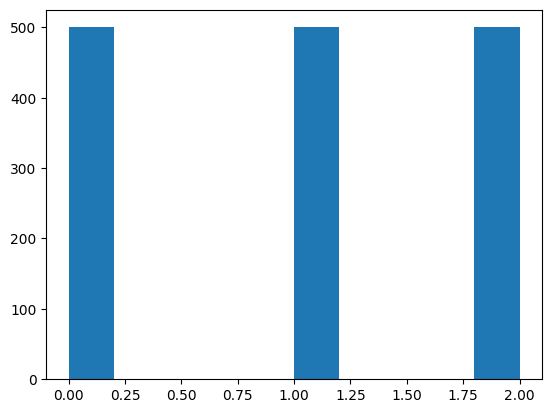

In [68]:
epsilon = 0.3 # R  the minimum radius
minimumSamples = 7 # M
dbs = DBSCAN(eps=epsilon, min_samples=minimumSamples) # Outputs : code_sample_indices_      labels_      components_
db = dbs.fit(X)
labels = db.labels_
plt.hist(labels)

### Distinguish outliers

Let's Replace all elements with 'True' in core_samples_mask that are in the cluster, 'False' if the points are outliers.


In [69]:
# Firts, create an array of booleans using the labels from db.
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)    # all false 
core_samples_mask[db.core_sample_indices_] = True            # anywere that is in cores should be true
core_samples_mask

array([ True,  True,  True, ...,  True,  True,  True])

In [70]:
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) # the lentgh of labels
print(n_clusters_)


n_clusters_=- (1 if -1 in labels else 0) #  if -1 in them, remove 1 of them     if 0 in them, remove 0 of them   



n_clusters_

3


0

In [71]:
# Remove repetition in labels by turning it into a set.
unique_labels = set(labels)
unique_labels

{np.int64(0), np.int64(1), np.int64(2)}

### Data Visualization


In [72]:
# Create colors for the clusters.
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))


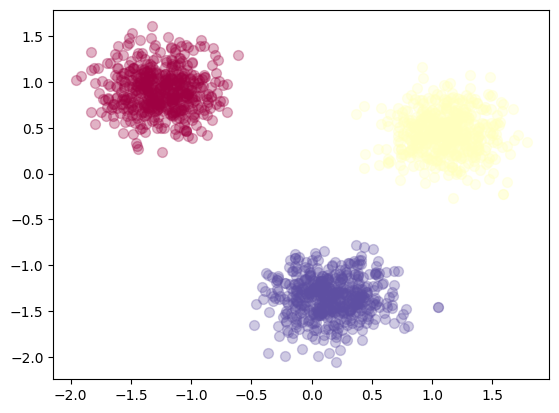

In [73]:
# Plot the points with colors
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'black'

    class_member_mask = (labels == k)

    # Plot the datapoints that are clustered
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1],s=50, c=[col], marker=u'o', alpha=0.3)

    # Plot the outliers
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1],s=50, c=[col], marker=u'o', alpha=0.5)

### Using K-Means Clustering 

C:\Users\Arya\AppData\Local\Temp\ipykernel_10116\893758542.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[my_members, 0], X[my_members, 1], c=col, marker=u'o', alpha=0.5)


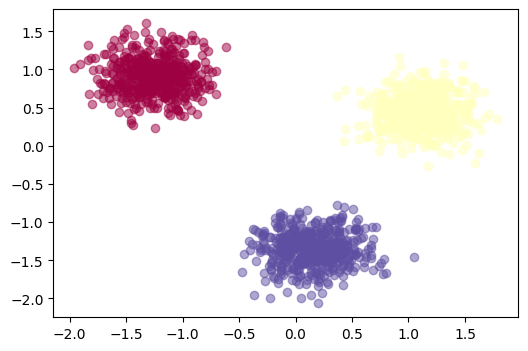

In [74]:


from sklearn.cluster import KMeans

k = 3
k_means3 = KMeans(init="k-means++", n_clusters=k, n_init=12)
k_means3.fit(X)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(k), colors):
    my_members = (k_means3.labels_ == k)
    plt.scatter(X[my_members, 0], X[my_members, 1], c=col, marker=u'o', alpha=0.5)
plt.show()



<h1 align=center> Weather Station Clustering using DBSCAN </h1>
<hr>

DBSCAN is especially very good for class identification in any spatial context. The wonderful attribute of DBSCAN is that the algorithm can find out any arbitrary shape cluster without getting affected by noise. For example, this data set is of the locations of weather stations in Canada.
\<Click 1>
For example, we can apply DBSCAN to find the group of stations which show the same weather condition. It has the advantage that it can not only find different arbitrary shaped clusters, but also find the denser part of data-centered samples by ignoring less-dense areas or noises.

Let's start by playing with the data through the following workflow: </font>


*   Loading data
*   Data cleaning
*   Data selection
*   Clusteing


## About the dataset

<h4 align = "center">
Environment Canada    
Monthly Values for July - 2015	
</h4>
<html>
<head>
<style>
table {
    font-family: arial, sans-serif;
    border-collapse: collapse;
    width: 100%;
}

td, th {
border: 1px solid #dddddd;
text-align: left;
padding: 8px;
}

tr:nth-child(even) {
background-color: #dddddd;
} </style>

</head>
<body>

<table>
  <tr>
    <th>Name in the table</th>
    <th>Meaning</th>
  </tr>
  <tr>
    <td><font color = "green"><strong>Stn_Name</font></td>
    <td><font color = "green"><strong>Station Name</font</td>
  </tr>
  <tr>
    <td><font color = "green"><strong>Lat</font></td>
    <td><font color = "green"><strong>Latitude (North+, degrees)</font></td>
  </tr>
  <tr>
    <td><font color = "green"><strong>Long</font></td>
    <td><font color = "green"><strong>Longitude (West - , degrees)</font></td>
  </tr>
  <tr>
    <td>Prov</td>
    <td>Province</td>
  </tr>
  <tr>
    <td>Tm</td>
    <td>Mean Temperature (°C)</td>
  </tr>
  <tr>
    <td>DwTm</td>
    <td>Days without Valid Mean Temperature</td>
  </tr>
  <tr>
    <td>D</td>
    <td>Mean Temperature difference from Normal (1981-2010) (°C)</td>
  </tr>
  <tr>
    <td><font color = "black">Tx</font></td>
    <td><font color = "black">Highest Monthly Maximum Temperature (°C)</font></td>
  </tr>
  <tr>
    <td>DwTx</td>
    <td>Days without Valid Maximum Temperature</td>
  </tr>
  <tr>
    <td><font color = "black">Tn</font></td>
    <td><font color = "black">Lowest Monthly Minimum Temperature (°C)</font></td>
  </tr>
  <tr>
    <td>DwTn</td>
    <td>Days without Valid Minimum Temperature</td>
  </tr>
  <tr>
    <td>S</td>
    <td>Snowfall (cm)</td>
  </tr>
  <tr>
    <td>DwS</td>
    <td>Days without Valid Snowfall</td>
  </tr>
  <tr>
    <td>S%N</td>
    <td>Percent of Normal (1981-2010) Snowfall</td>
  </tr>
  <tr>
    <td><font color = "green"><strong>P</font></td>
    <td><font color = "green"><strong>Total Precipitation (mm)</font></td>
  </tr>
  <tr>
    <td>DwP</td>
    <td>Days without Valid Precipitation</td>
  </tr>
  <tr>
    <td>P%N</td>
    <td>Percent of Normal (1981-2010) Precipitation</td>
  </tr>
  <tr>
    <td>S_G</td>
    <td>Snow on the ground at the end of the month (cm)</td>
  </tr>
  <tr>
    <td>Pd</td>
    <td>Number of days with Precipitation 1.0 mm or more</td>
  </tr>
  <tr>
    <td>BS</td>
    <td>Bright Sunshine (hours)</td>
  </tr>
  <tr>
    <td>DwBS</td>
    <td>Days without Valid Bright Sunshine</td>
  </tr>
  <tr>
    <td>BS%</td>
    <td>Percent of Normal (1981-2010) Bright Sunshine</td>
  </tr>
  <tr>
    <td>HDD</td>
    <td>Degree Days below 18 °C</td>
  </tr>
  <tr>
    <td>CDD</td>
    <td>Degree Days above 18 °C</td>
  </tr>
  <tr>
    <td>Stn_No</td>
    <td>Climate station identifier (first 3 digits indicate   drainage basin, last 4 characters are for sorting alphabetically).</td>
  </tr>
  <tr>
    <td>NA</td>
    <td>Not Available</td>
  </tr>

</table>

</body>
</html>


### 1- Load the dataset

We will import the .csv then we creates the columns for year, month and day.


In [75]:
import csv
import pandas as pd
import numpy as np

filename='weather-stations20140101-20141231.csv'

#Read csv
pdf = pd.read_csv(filename)
pdf.head(5)

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
0,CHEMAINUS,48.935,-123.742,BC,8.2,0.0,NaN,13.5,0.0,1.0,...,0.0,NaN,0.0,12.0,NaN,NaN,NaN,273.3,0.0,1011500
1,COWICHAN LAKE FORESTRY,48.824,-124.133,BC,7.0,0.0,3.0,15.0,0.0,-3.0,...,0.0,104.0,0.0,12.0,NaN,NaN,NaN,307.0,0.0,1012040
2,LAKE COWICHAN,48.829,-124.052,BC,6.8,13.0,2.8,16.0,9.0,-2.5,...,9.0,NaN,NaN,11.0,NaN,NaN,NaN,168.1,0.0,1012055
3,DISCOVERY ISLAND,48.425,-123.226,BC,NaN,NaN,NaN,12.5,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1012475
4,DUNCAN KELVIN CREEK,48.735,-123.728,BC,7.7,2.0,3.4,14.5,2.0,-1.0,...,2.0,NaN,NaN,11.0,NaN,NaN,NaN,267.7,0.0,1012573


### 2- Cleaning

Let's remove rows that don't have any value in the **Tm** field.


In [76]:
pdf = pdf[pd.notnull(pdf["Tm"])]
pdf = pdf.reset_index(drop=True)
pdf.head(5)

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
0,CHEMAINUS,48.935,-123.742,BC,8.2,0.0,NaN,13.5,0.0,1.0,...,0.0,NaN,0.0,12.0,NaN,NaN,NaN,273.3,0.0,1011500
1,COWICHAN LAKE FORESTRY,48.824,-124.133,BC,7.0,0.0,3.0,15.0,0.0,-3.0,...,0.0,104.0,0.0,12.0,NaN,NaN,NaN,307.0,0.0,1012040
2,LAKE COWICHAN,48.829,-124.052,BC,6.8,13.0,2.8,16.0,9.0,-2.5,...,9.0,NaN,NaN,11.0,NaN,NaN,NaN,168.1,0.0,1012055
3,DUNCAN KELVIN CREEK,48.735,-123.728,BC,7.7,2.0,3.4,14.5,2.0,-1.0,...,2.0,NaN,NaN,11.0,NaN,NaN,NaN,267.7,0.0,1012573
4,ESQUIMALT HARBOUR,48.432,-123.439,BC,8.8,0.0,NaN,13.1,0.0,1.9,...,8.0,NaN,NaN,12.0,NaN,NaN,NaN,258.6,0.0,1012710


### 3- Clustering of stations based on their location i.e. Lat & Lon

**DBSCAN** form sklearn library can runs DBSCAN clustering from vector array or distance matrix. In our case, we pass it the Numpy array Clus_dataSet to find core samples of high density and expands clusters from them.


In [77]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import sklearn.utils
import numpy as np


if 'Lat' in pdf.columns and 'Long' in pdf.columns:

    Clus_dataSet = pdf[['Lat', 'Long']]
    Clus_dataSet = np.nan_to_num(Clus_dataSet)
    Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)  # Standardize the data



    db = DBSCAN(eps=0.15, min_samples=10).fit(Clus_dataSet)
    


    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    labels = db.labels_


    pdf["Clus_Db"] = labels




    realClusterNum = len(set(labels)) - (1 if -1 in labels else 0)
    clusterNum = len(set(labels))




    print(pdf[["Stn_Name", "Tx", "Tm", "Clus_Db"]].head(5))

else:
    print("Columns 'Lat' and 'Long' are not in the DataFrame.")


                 Stn_Name    Tx   Tm  Clus_Db
0               CHEMAINUS  13.5  8.2        0
1  COWICHAN LAKE FORESTRY  15.0  7.0        0
2           LAKE COWICHAN  16.0  6.8        0
3     DUNCAN KELVIN CREEK  14.5  7.7        0
4       ESQUIMALT HARBOUR  13.1  8.8        0


As you can see for outliers, the cluster label is -1


In [78]:
set(labels)

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)}

### 4- Visualization of clusters based on location

Now, we can visualize the clusters using basemap:


Cluster 0, Avg Temp: -5.217089678510997
Cluster 1, Avg Temp: -21.10909090909091
Cluster 2, Avg Temp: -15.310840108401086
Cluster 3, Avg Temp: -8.083720930232559


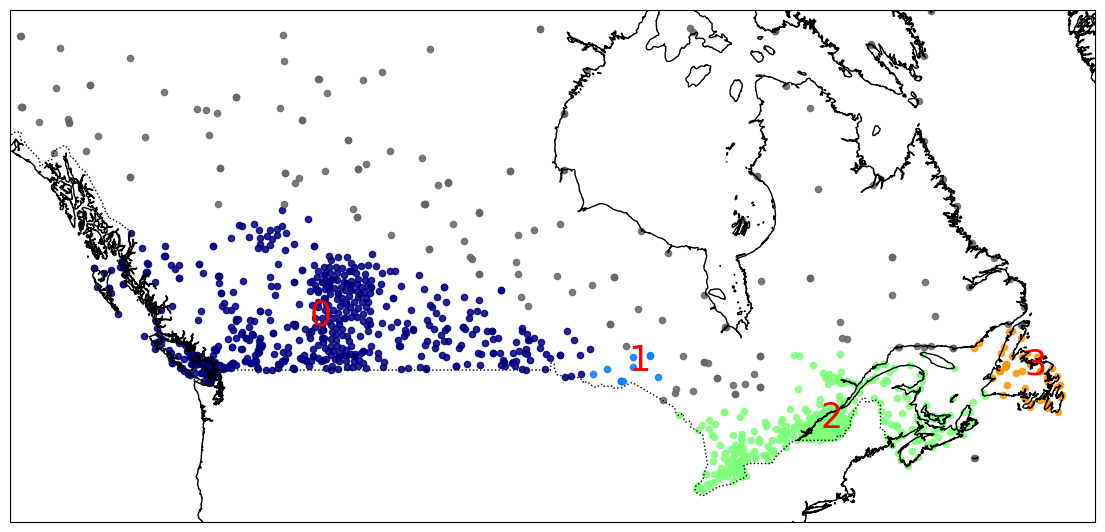

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import cm






fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={'projection': ccrs.Mercator()})



ax.set_extent([llon, ulon, llat, ulat], crs=ccrs.PlateCarree())


ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)


ax.add_feature(cfeature.LAND, facecolor='white', alpha=0.3)


colors = cm.jet(np.linspace(0.0, 1.0, clusterNum))

# Visualization
for clust_number in set(labels):

    c = ([0.4, 0.4, 0.4]) if clust_number == -1 else colors[int(clust_number) % clusterNum]
    
    # Filter data for the current cluster
    clust_set = pdf[pdf.Clus_Db == clust_number]
    

    ax.scatter(clust_set['Long'], clust_set['Lat'], color=c, marker='o', s=20, alpha=0.85, transform=ccrs.PlateCarree())
    


    if clust_number != -1:
        cenx = np.mean(clust_set['Long'])
        ceny = np.mean(clust_set['Lat'])
        ax.text(cenx, ceny, str(clust_number), fontsize=25, color='red', transform=ccrs.PlateCarree())
        print(f"Cluster {clust_number}, Avg Temp: {np.mean(clust_set.Tm)}")

plt.show()


### 5- Clustering of stations based on their location, mean, max, and min Temperature

In this section we re-run DBSCAN, but this time on a 5-dimensional dataset:


In [80]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import sklearn.utils




sklearn.utils.check_random_state(1000)


Clus_dataSet = pdf[['Lat', 'Long', 'Tx', 'Tm', 'Tn']]  
Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet) 



db = DBSCAN(eps=0.3, min_samples=10).fit(Clus_dataSet)




core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True



labels = db.labels_




pdf["Clus_Db"] = labels


realClusterNum = len(set(labels)) - (1 if -1 in labels else 0)
clusterNum = len(set(labels))


print(pdf[["Stn_Name", "Tx", "Tm", "Clus_Db"]].head(5))


                 Stn_Name    Tx   Tm  Clus_Db
0               CHEMAINUS  13.5  8.2        0
1  COWICHAN LAKE FORESTRY  15.0  7.0        0
2           LAKE COWICHAN  16.0  6.8        0
3     DUNCAN KELVIN CREEK  14.5  7.7        0
4       ESQUIMALT HARBOUR  13.1  8.8        0


### 6- Visualization of clusters based on location and Temperture


Cluster 0, Avg Temp: 6.23820224719101
Cluster 1, Avg Temp: -0.5523809523809524
Cluster 2, Avg Temp: -3.244444444444445
Cluster 3, Avg Temp: -13.748425196850395
Cluster 4, Avg Temp: -4.153703703703704
Cluster 5, Avg Temp: -16.420983606557375
Cluster 6, Avg Temp: -10.178947368421053
Cluster 7, Avg Temp: -4.371428571428572


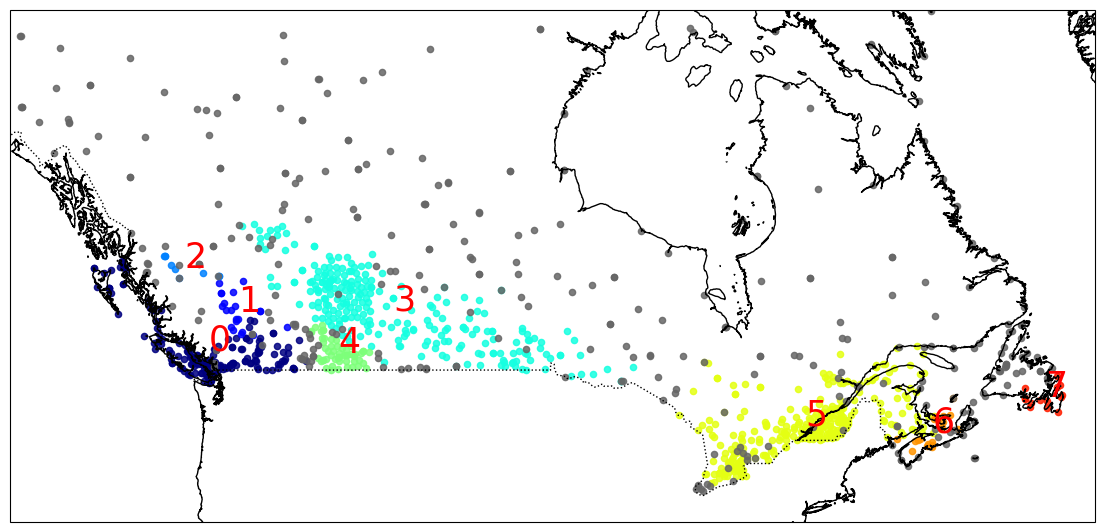

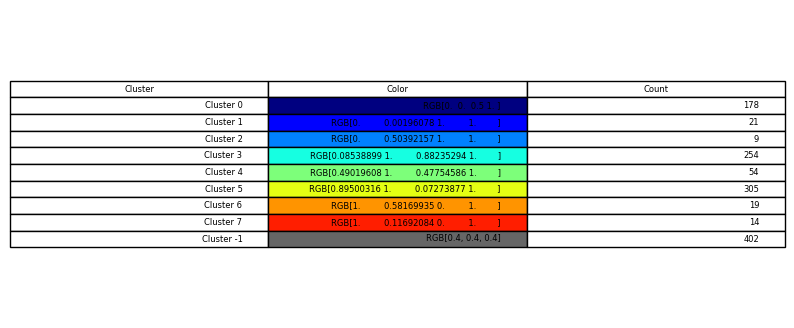

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import cm
from collections import Counter




fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={'projection': ccrs.Mercator()})


ax.set_extent([llon, ulon, llat, ulat], crs=ccrs.PlateCarree())


ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)



ax.add_feature(cfeature.LAND, facecolor='white', alpha=0.3)



colors = cm.jet(np.linspace(0.0, 1.0, clusterNum))


color_count = Counter(labels)




for clust_number in set(labels):
    c = ([0.4, 0.4, 0.4]) if clust_number == -1 else colors[int(clust_number) % clusterNum]
    

    clust_set = pdf[pdf.Clus_Db == clust_number]
    

    ax.scatter(clust_set['Long'], clust_set['Lat'], color=c, marker='o', s=20, alpha=0.85, transform=ccrs.PlateCarree())
    


    if clust_number != -1:
        cenx = np.mean(clust_set['Long'])
        ceny = np.mean(clust_set['Lat'])
        ax.text(cenx, ceny, str(clust_number), fontsize=25, color='red', transform=ccrs.PlateCarree())
        print(f"Cluster {clust_number}, Avg Temp: {np.mean(clust_set.Tm)}")






# MAP
plt.show()



fig, ax = plt.subplots(figsize=(10, 4))




table_data = []
for clust_number in set(labels):
    color = ([0.4, 0.4, 0.4]) if clust_number == -1 else colors[int(clust_number) % clusterNum]
    count = color_count[clust_number]
    
    table_data.append([f'Cluster {clust_number}', f'RGB{color}', count])




table = ax.table(cellText=table_data, colLabels=['Cluster', 'Color', 'Count'], loc='center')



for (i, clust_number) in enumerate(set(labels)):
    color = ([0.4, 0.4, 0.4]) if clust_number == -1 else colors[int(clust_number) % clusterNum]
    table[(i+1, 1)].set_facecolor(color) 
    

ax.axis('off')


plt.show()
